In [1]:
# Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import LSTM, Dense
print('All packages loaded')


All packages loaded


# Introduction
In this notebook we calibrate a number of models on EURIBOR daily data, with the aim to compare their performance with a simple Random Walk model. The models that we are going to use can be categorized in 2 different field of study:
1. **Mathematical Finance**: Vasicek, CIR
2. **Machine Learning**: Random Forest, LSTM

For each model we perform a **rolling window** approach, with a number of **30** observations for each step, and forecast: 
*1-day, 1_week, 1_month, 3_months ahead*. 

# Import EURIBOR data
First step is importing the full dataset, clean it, and keep only the time series we are working on.

In [2]:
df = pd.read_excel('EURIBOR.xlsx')

# Let's keep the last 600 obs for computational reasons
df = df.iloc[-600:, :]
df.reset_index(drop=True, inplace=True)
df.tail()

,Date,1 week,1 month,3 month,6 month,12 month
595,2023-09-25,3.883,3.865,3.977,4.122,4.208
596,2023-09-26,3.882,3.843,3.941,4.090,4.199
597,2023-09-27,3.881,3.858,3.972,4.136,4.200
598,2023-09-28,3.892,3.845,3.955,4.125,4.221
599,2023-09-29,3.872,3.847,3.952,4.125,4.228


Let's keep the 1 week maturity rates only, which are the best proxy for **short term rates**, and keep the Date as a singular Series. This is important as the Mathematical Finance models we use, have been theoretically built to model short term rates in continuous time. 

In [3]:
# keep dates and 1-week rates
dates = df.Date
euribor_ir = df.iloc[:, 1] / 100
euribor_ir.head()

0   -0.00562
1   -0.00562
2   -0.00558
3   -0.00558
4   -0.00565
Name: 1 week, dtype: float64

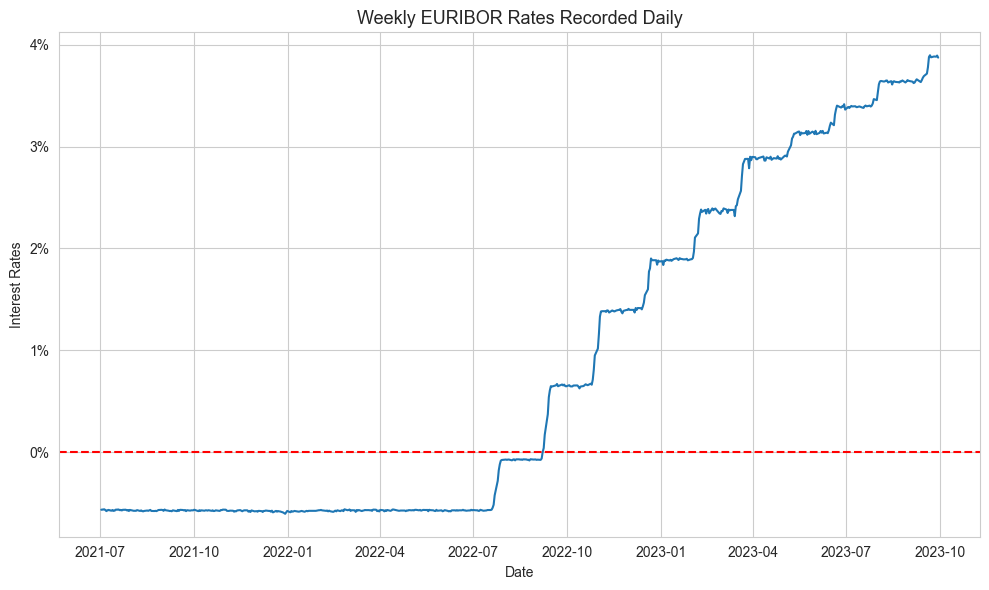

In [4]:
## Time series plot

df2 = df.copy()
df2.index = df.iloc[:, 0]
df2 = df2.iloc[:, 1]/100

plt.figure(figsize=(10, 6))
# Set Seaborn style
sns.set_style("whitegrid")
# Create the time series plot using Seaborn
sns.lineplot(data=df2)
# Set plot labels and title
plt.xlabel('Date')
plt.ylabel('Interest Rates')
plt.title('Weekly EURIBOR Rates Recorded Daily', fontsize=13)
# Show grid
plt.grid(True)
# Function to format y-axis labels
def percentage(x, pos):
    return f'{x:.0%}'  # Change the format as desired, here it shows as whole percentage without decimals
# Apply the custom formatter to the y-axis ticks
plt.gca().yaxis.set_major_formatter(mtick.FuncFormatter(percentage))
# Add a red line at y=0
plt.axhline(y=0, color='red', linestyle='--')  # You can customize linestyle as needed
# Show plot
plt.tight_layout()
plt.show()

# Random Walk 
This simple model can be mathematically expressed as follows:

$i_{t+\delta t} = i_{t} + \epsilon$

Where $\epsilon$ is a disturbance term with zero mean. 
This allows us to employ the **Random Walk** as a straightforward benchmark, where the optimal prediction for rates at time $t+1$ is merely the rates at time $t$. In essence, our time series is inherently unpredictable, as there is no additional information that can be harnessed for forecasting purposes. 

In [5]:
df = euribor_ir.copy()
df = pd.DataFrame({'series1': df})
df = df.join(euribor_ir.shift(1),  how='left')
df.columns = ['rates t', 'rates t-1']
df = df.dropna()
df.reset_index(inplace=True)
df = df.iloc[:, 1:]
print(df.head())

# split y and X
y = df['rates t']
X = df[['rates t-1']]

   rates t  rates t-1
0 -0.00562   -0.00562
1 -0.00558   -0.00562
2 -0.00558   -0.00558
3 -0.00565   -0.00558
4 -0.00565   -0.00565


In [6]:
# Variables of interest for the calibration
ts_length = df.shape[0]
n_obs = 30
max_time_step = 90

In [7]:
pred1_v = np.zeros(ts_length-(n_obs+max_time_step-1))
pred7_v = np.zeros(ts_length-(n_obs+max_time_step-1))
pred30_v = np.zeros(ts_length-(n_obs+max_time_step-1))
pred90_v = np.zeros(ts_length-(n_obs+max_time_step-1))

exact1_v = np.zeros(ts_length-(n_obs+max_time_step-1))
exact7_v = np.zeros(ts_length-(n_obs+max_time_step-1))
exact30_v = np.zeros(ts_length-(n_obs+max_time_step-1))
exact90_v = np.zeros(ts_length-(n_obs+max_time_step-1))

"""
create a for loop for the rolling window, but only for those
timeframes where backtesting is possible
"""
for n in range(ts_length-n_obs):

    # by doing that I keep all the observations from n to (n+n_obs-1)
    X_train = X.iloc[n:n+n_obs, :]
    y_train = y.iloc[n:n+n_obs]
    prediction_index = y_train.index[-1]

    # Need to break the loop if my max prediction cannot be backtested
    if (prediction_index + max_time_step) > y.index[-1]:
        break

    # predictions and exact values at 4 time steps
    r0 = y_train.iloc[-1]

    pred1 = r0
    pred7 = r0
    pred30 = r0
    pred90 = r0

    exact1 = y.iloc[prediction_index + 1]
    exact7 = y.iloc[prediction_index + 7]
    exact30 = y.iloc[prediction_index + 30]
    exact90 = y.iloc[prediction_index + 90]

    # store the predictions and the exact values
    pred1_v[n] = pred1
    pred7_v[n] = pred7
    pred30_v[n] = pred30
    pred90_v[n] = pred90

    exact1_v[n] = exact1
    exact7_v[n] = exact7
    exact30_v[n] = exact30
    exact90_v[n] = exact90

In [8]:
# Create a dataframe with all the predictions and one with all exact values
pred_RW = {
    '1 step pred': pred1_v,
    '7 step pred': pred7_v,
    '30 step pred': pred30_v,
    '90 step pred': pred90_v
}

exact_rates = {
    '1 step exact': exact1_v,
    '7 step exact': exact7_v,
    '30 step exact': exact30_v,
    '90 step exact': exact90_v
}

pred_RW = pd.DataFrame(pred_RW)
exact_rates = pd.DataFrame(exact_rates)
pred_RW.index = dates.iloc[n_obs:pred_RW.shape[0]+n_obs]
exact_rates.index = dates.iloc[n_obs:pred_RW.shape[0]+n_obs]

In [9]:
# Compute MSE
SE_RW = pd.DataFrame(columns=['1 step ahead', '7 steps ahead', '30 steps ahead', '90 steps ahead'])
for n in range(4):
    SE_RW[SE_RW.columns[n]] = (pred_RW.iloc[:, n] - exact_rates.iloc[:, n])**2

SE_RW.head()

,1 step ahead,7 steps ahead,30 steps ahead,90 steps ahead
Date,,,,
2021-07-23,0.000000e+00,4.000000e-10,4.000000e-10,2.500000e-09
2021-07-23,1.000000e-10,1.210000e-08,0.000000e+00,2.500000e-09
2021-07-26,0.000000e+00,1.440000e-08,9.000000e-10,3.610000e-08
2021-07-26,3.600000e-09,4.000000e-10,1.210000e-08,1.440000e-08
2021-07-27,0.000000e+00,1.600000e-09,6.400000e-09,2.560000e-08


# Vasicek Model

In [10]:
# Variables of interest for the calibration
pred1_v = np.zeros(ts_length-(n_obs+max_time_step-1))
pred7_v = np.zeros(ts_length-(n_obs+max_time_step-1))
pred30_v = np.zeros(ts_length-(n_obs+max_time_step-1))
pred90_v = np.zeros(ts_length-(n_obs+max_time_step-1))

In [11]:
for n in range(ts_length-n_obs):

    # linear regression needed for the Vasicek calibration
    model = LinearRegression()

    # by doing that I keep all the observations from n to (n+n_obs-1)
    X_train = X.iloc[n:n+n_obs, :]
    y_train = y.iloc[n:n+n_obs]
    prediction_index = y_train.index[-1]

    # Need to break the loop if my max prediction cannot be backtested
    if (prediction_index + max_time_step) > y.index[-1]:
        break

    # fit the model
    model.fit(X_train, y_train)

    # get parameters of the linear regression
    intercept = model.intercept_
    slope = model.coef_[0]

    # get the parameter of interest for Vasicek
    dt = 1/252
    k = (1-slope)/dt
    theta = intercept / (1-slope)

    # predictions at 4 time steps
    r0 = y.iloc[prediction_index]

    pred1 = r0 * np.exp(-k*dt) + theta * (1 - np.exp(-k*dt))
    pred7 = r0 * np.exp(-k*7*dt) + theta * (1 - np.exp(-k*7*dt))
    pred30 = r0 * np.exp(-k*30*dt) + theta * (1 - np.exp(-k*30*dt))
    pred90 = r0 * np.exp(-k*90*dt) + theta * (1 - np.exp(-k*90*dt))

    # store the predictions
    pred1_v[n] = pred1
    pred7_v[n] = pred7
    pred30_v[n] = pred30
    pred90_v[n] = pred90

In [12]:
# Create a dataframe with all the predictions and one with all exact values
pred_vsk = {
    '1 step pred': pred1_v,
    '7 step pred': pred7_v,
    '30 step pred': pred30_v,
    '90 step pred': pred90_v
}

pred_VSK = pd.DataFrame(pred_vsk)
pred_VSK.index = dates.iloc[n_obs:pred_RW.shape[0]+n_obs]

In [13]:
# Compute MSE
SE_VSK = pd.DataFrame(columns=['1 step ahead', '7 steps ahead', '30 steps ahead', '90 steps ahead'])
for n in range(4):
    SE_VSK[SE_VSK.columns[n]] = (pred_VSK.iloc[:, n] - exact_rates.iloc[:, n])**2

SE_VSK.head()

,1 step ahead,7 steps ahead,30 steps ahead,90 steps ahead
Date,,,,
2021-07-23,1.180854e-10,9.672136e-11,1.311708e-10,3.439884e-10
2021-07-23,4.443328e-10,6.368532e-09,1.009806e-09,3.320583e-10
2021-07-26,2.618628e-10,6.016707e-09,2.034421e-10,2.123917e-08
2021-07-26,1.788362e-09,5.732146e-10,4.178324e-09,5.571121e-09
2021-07-27,2.838244e-11,7.049232e-10,4.365769e-09,3.025027e-08


# CIR

In [14]:
# Make all the rates positive
count_negatives = 0
for value in y:
    if value < 0:
        count_negatives += 1

print(f'the number of negative interest rates is: {count_negatives}')
shift = np.percentile(y, 99)
print(shift)

# split y and X
y_shift = y.copy() + shift
X_shift = X.copy() + shift
X_shift = X_shift['rates t-1'] # make a Series for sequent computations

count_negatives = 0
for value in y_shift:
    if value < 0:
        count_negatives += 1

print(f'the number of negative interest rates is: {count_negatives}')

the number of negative interest rates is: 325
0.038750599999999996
the number of negative interest rates is: 0


In [15]:
# Variables of interest for the calibration
pred1_v = np.zeros(ts_length-(n_obs+max_time_step-1))
pred7_v = np.zeros(ts_length-(n_obs+max_time_step-1))
pred30_v = np.zeros(ts_length-(n_obs+max_time_step-1))
pred90_v = np.zeros(ts_length-(n_obs+max_time_step-1))

In [16]:
for n in range(ts_length-n_obs):

    # linear regression needed for CIR calibration
    model = LinearRegression(fit_intercept=False)

    # by doing that I keep all the observations from n to (n+n_obs-1)
    X_train = X_shift.iloc[n:n+n_obs]
    y_train = y_shift.iloc[n:n+n_obs]
    prediction_index = y_train.index[-1]

    # Need to break the loop if my max prediction cannot be backtested
    if (prediction_index + max_time_step) > y_shift.index[-1]:
        break

    y_cir = (y_train - X_train) / np.sqrt(X_train)
    z1 = dt / np.sqrt(X_train)
    z2 = dt * np.sqrt(X_train)
    X_cir = np.column_stack((z1, z2))

    model.fit(X_cir, y_cir)

    # Calculate the predicted values (y_hat), residuals and the parameters
    beta1 = model.coef_[0]
    beta2 = model.coef_[1]

    # get the parameter of interest for CIR
    k = -beta2
    theta = beta1/k
    dt = 1/252

    # predictions at 4 time steps
    r0 = y_shift.iloc[prediction_index]

    pred1 = r0 * np.exp(-k*dt) + theta * (1 - np.exp(-k*dt)) - shift
    pred7 = r0 * np.exp(-k*7*dt) + theta * (1 - np.exp(-k*7*dt)) - shift
    pred30 = r0 * np.exp(-k*30*dt) + theta * (1 - np.exp(-k*30*dt)) - shift
    pred90 = r0 * np.exp(-k*90*dt) + theta * (1 - np.exp(-k*90*dt)) - shift

In [17]:
# Create a dataframe with all the predictions and one with all exact values
pred_CIR = {
    '1 step pred': pred1_v,
    '7 step pred': pred7_v,
    '30 step pred': pred30_v,
    '90 step pred': pred90_v
}

pred_CIR = pd.DataFrame(pred_vsk)
pred_CIR.index = dates.iloc[n_obs:pred_RW.shape[0]+n_obs]

In [18]:
# Compute MSE
SE_CIR = pd.DataFrame(columns=['1 step ahead', '7 steps ahead', '30 steps ahead', '90 steps ahead'])
for n in range(4):
    SE_CIR[SE_CIR.columns[n]] = (pred_CIR.iloc[:, n] - exact_rates.iloc[:, n])**2

SE_CIR.head()

,1 step ahead,7 steps ahead,30 steps ahead,90 steps ahead
Date,,,,
2021-07-23,1.180854e-10,9.672136e-11,1.311708e-10,3.439884e-10
2021-07-23,4.443328e-10,6.368532e-09,1.009806e-09,3.320583e-10
2021-07-26,2.618628e-10,6.016707e-09,2.034421e-10,2.123917e-08
2021-07-26,1.788362e-09,5.732146e-10,4.178324e-09,5.571121e-09
2021-07-27,2.838244e-11,7.049232e-10,4.365769e-09,3.025027e-08


# Random Forest

In [19]:
# Variables of interest for the calibration
pred1_v = np.zeros(ts_length-(n_obs+max_time_step-1))

In [20]:
for n in range(ts_length-n_obs):
    #choose the model
    model = RandomForestRegressor(n_estimators=25, random_state=0)
    num_lags = 5

    # by doing that I keep all the observations from n to (n+n_obs-1)
    y_train = y[n:n+n_obs]
    prediction_index = y_train.index[-1]

    # Need to break the loop if my max prediction cannot be backtested
    if (prediction_index + max_time_step) > y.index[-1]:
        break

    # fill the lagged data dataframe
    lagged_data = pd.DataFrame()
    for lag in range(1, num_lags + 1):
        lagged_data[f"Lag_{lag}"] = y_train.shift(lag)

    # create initial df
    lagged_data = lagged_data.dropna()
    target = pd.DataFrame(y_train[num_lags:])

    # reset indexes
    lagged_data.reset_index(inplace=True)
    target.reset_index(inplace=True)
    lagged_data = lagged_data.iloc[:, 1:]
    target = pd.DataFrame(target.iloc[:, 1])

    # create the lagged data to predict t+1 observation
    X_test = lagged_data.iloc[-1, :]
    new_lag_1 = target.iloc[-1]
    X_test_new = pd.concat([pd.Series(new_lag_1), X_test[:-1]])
    X_test_new.index = X_test.index

    # Train a random forest model
    model.fit(lagged_data, np.ravel(target))

    # store the predictions
    pred1_v[n] = model.predict(X_test_new.to_frame().T)

In [21]:
# Create a dataframe with all the predictions and one with all exact values
pred_rf = {
    '1 step pred': pred1_v,
}

pred_rf = pd.DataFrame(pred_rf)
pred_rf.index = dates.iloc[n_obs:pred_RW.shape[0]+n_obs]

In [22]:
# Compute MSE
SE_rf = pd.DataFrame(columns=['1 step ahead'])
SE_rf['1 step ahead'] = (pred_rf.iloc[:, 0] - exact_rates.iloc[:, 0])**2

SE_rf.head()

,1 step ahead
Date,
2021-07-23,1.742400e-10
2021-07-23,1.324960e-09
2021-07-26,1.936000e-11
2021-07-26,2.580640e-09
2021-07-27,1.345600e-10


# LSTM

In [23]:
# Variables of interest for the calibration
pred1_v = np.zeros(ts_length-(n_obs+max_time_step-1))

In [24]:
counter = 0
for n in range(ts_length-n_obs):

    # by doing that I keep all the observations from n to (n+n_obs-1)
    y_train = y[n:n+n_obs]
    prediction_index = y_train.index[-1]
    interest_rates = y_train.values

    # Need to break the loop if my max prediction cannot be backtested
    if (prediction_index + max_time_step) > y.index[-1]:
        break

    print(f'this is the loop n {counter}')
    counter += 1
    # Normalize the data using MinMaxScaler
    scaler = MinMaxScaler(feature_range=(0, 1))
    interest_rates_normalized = scaler.fit_transform(interest_rates.reshape(-1, 1))

    # Split the data into input (X) and output (y)
    X_lstm = interest_rates_normalized[:-1]
    y_lstm = interest_rates_normalized[1:]

    # Reshape data for LSTM model (samples, time steps, features)
    X_lstm = np.reshape(X_lstm, (X_lstm.shape[0], 1, 1))

    # Build the LSTM model
    model = Sequential()
    model.add(LSTM(units=5, input_shape=(X_lstm.shape[1], X_lstm.shape[2])))
    model.add(Dense(units=1))

    model.compile(optimizer='adam', loss='mean_squared_error')

    # Train the model
    model.fit(X_lstm, y_lstm, epochs=10, batch_size=1, verbose=1)

    # Predict using the trained model for the 31st observation
    last_observation = interest_rates_normalized[-1].reshape(1, 1, 1)
    predicted_next_interest = model.predict(last_observation)
    predicted_next_interest = scaler.inverse_transform(predicted_next_interest)

    # store the predictions
    pred1_v[n] = predicted_next_interest

this is the loop n 0


Epoch 1/10

29/29 [==============================] - 3s 2ms/step - loss: 0.2946
Epoch 2/10
29/29 [==============================] - 0s 2ms/step - loss: 0.2516
Epoch 3/10
29/29 [==============================] - 0s 2ms/step - loss: 0.2080
Epoch 4/10
29/29 [==============================] - 0s 2ms/step - loss: 0.1693
Epoch 5/10
29/29 [==============================] - 0s 1ms/step - loss: 0.1359
Epoch 6/10
29/29 [==============================] - 0s 1ms/step - loss: 0.1071
Epoch 7/10
29/29 [==============================] - 0s 2ms/step - loss: 0.0883
Epoch 8/10
29/29 [==============================] - 0s 2ms/step - loss: 0.0730
Epoch 9/10
29/29 [==============================] - 0s 2ms/step - loss: 0.0649
Epoch 10/10
1/1 [==============================] - 1s 727ms/step
this is the loop n 1
Epoch 1/10
29/29 [==============================] - 2s 2ms/step - loss: 0.2608
Epoch 2/10
29/29 [==============================] - 0s 2ms/step - loss: 0.2037
Epoch 3/10
29/29 [===

In [25]:
# Create a dataframe with all the predictions
pred_LSTM = {
    '1 step pred': pred1_v,
}

pred_LSTM = pd.DataFrame(pred_LSTM)
pred_LSTM.index = dates.iloc[n_obs:pred_RW.shape[0]+n_obs]

In [51]:
# Compute MSE
SE_LSTM = pd.DataFrame(columns=['1 step ahead'])
SE_LSTM['1 step ahead'] = (pred_LSTM.iloc[:, 0] - exact_rates.iloc[:, 0])**2

SE_LSTM.head()

,1 step ahead
Date,
2021-07-23,9.113385e-10
2021-07-23,1.506399e-09
2021-07-26,3.411150e-09
2021-07-26,2.721984e-10
2021-07-27,5.764829e-12


# Forecasting Comparison

In [27]:
# We need to convert any zero error of RW to 0.00000000001
SE_RW = SE_RW.replace(0, 0.00000000001)
SE_RW

,1 step ahead,7 steps ahead,30 steps ahead,90 steps ahead
Date,,,,
2021-07-23,1.000000e-11,4.000000e-10,4.000000e-10,2.500000e-09
2021-07-23,1.000000e-10,1.210000e-08,1.000000e-11,2.500000e-09
2021-07-26,1.000000e-11,1.440000e-08,9.000000e-10,3.610000e-08
2021-07-26,3.600000e-09,4.000000e-10,1.210000e-08,1.440000e-08
2021-07-27,1.000000e-11,1.600000e-09,6.400000e-09,2.560000e-08
...,...,...,...,...
2023-05-22,4.000000e-08,1.000000e-08,6.553600e-06,5.640010e-05
2023-05-23,1.369000e-07,4.000000e-10,5.107600e-06,5.329000e-05
2023-05-24,1.369000e-07,3.600000e-09,7.452900e-06,5.867560e-05


In [28]:
# compute all the scores
F_score_RW = (SE_RW - SE_RW) / SE_RW
F_score_VSK = (SE_RW - SE_VSK) / SE_RW
F_score_CIR = (SE_RW - SE_CIR) / SE_RW
F_score_rf = (SE_RW - SE_rf) / SE_RW
F_score_LSTM = (SE_RW - SE_LSTM) / SE_RW

print(F_score_RW.head())

            1 step ahead  7 steps ahead  30 steps ahead  90 steps ahead
Date                                                                   
2021-07-23           0.0            0.0             0.0             0.0
2021-07-23           0.0            0.0             0.0             0.0
2021-07-26           0.0            0.0             0.0             0.0
2021-07-26           0.0            0.0             0.0             0.0
2021-07-27           0.0            0.0             0.0             0.0


In [29]:
# we need to eliminate all the dates with RW error = 0, as it will make the other scores = inf
F_score_RW.isna().sum().sum()

0

## Summary of Each Model's Metric

In [30]:
F_score_VSK.describe()

,1 step ahead,7 steps ahead,30 steps ahead,90 steps ahead
count,480.000000,4.800000e+02,4.800000e+02,4.800000e+02
mean,-439.559140,-2.040310e+05,-7.966542e+33,-1.371764e+107
std,6022.185467,4.157322e+06,1.745382e+35,3.005383e+108
min,-122312.227995,-9.102959e+07,-3.823940e+36,-6.584465e+109
25%,-4.976125,-4.583105e+01,-1.837168e+00,-1.496581e+00
50%,-0.200638,-3.313078e-01,1.009842e-01,6.958679e-04
75%,0.588236,6.069805e-01,7.097269e-01,4.070690e-01
max,1.000000,9.999825e-01,9.999317e-01,9.996095e-01


In [31]:
F_score_CIR.describe()

,1 step ahead,7 steps ahead,30 steps ahead,90 steps ahead
count,480.000000,4.800000e+02,4.800000e+02,4.800000e+02
mean,-439.559140,-2.040310e+05,-7.966542e+33,-1.371764e+107
std,6022.185467,4.157322e+06,1.745382e+35,3.005383e+108
min,-122312.227995,-9.102959e+07,-3.823940e+36,-6.584465e+109
25%,-4.976125,-4.583105e+01,-1.837168e+00,-1.496581e+00
50%,-0.200638,-3.313078e-01,1.009842e-01,6.958679e-04
75%,0.588236,6.069805e-01,7.097269e-01,4.070690e-01
max,1.000000,9.999825e-01,9.999317e-01,9.996095e-01


In [32]:
F_score_rf['1 step ahead'].describe()

count      480.000000
mean       -63.658076
std        552.303910
min     -10136.856000
25%         -3.989877
50%          0.025666
75%          0.743109
max          1.000000
Name: 1 step ahead, dtype: float64

In [33]:
F_score_LSTM['1 step ahead'].describe()

count    4.800000e+02
mean    -3.085792e+04
std      2.267724e+05
min     -3.553164e+06
25%     -2.540682e+02
50%     -5.423405e+00
75%      3.132286e-01
max      9.999999e-01
Name: 1 step ahead, dtype: float64

In [34]:
# Define some functions for our task
#---------------------------------------------------------
def change_values(val):
    if val > 0:
        return 1
    elif val < 0:
        return -1
    else:
        return 0

#---------------------------------------------------------

def pos_neg_plot(data, title):
    # Creating a figure and axis
    fig, ax = plt.subplots(figsize=(15, 6))

    # Creating an area plot for values of 1 and -1
    x = range(len(data))  # X-axis values (assumed indices)
    y = data.values  # Y-axis values from the DataFrame

    for i, val in enumerate(y):
        if val == 1:
            plt.fill_between(x[i:i+1], 0, 1, color='green')
        elif val == -1:
            plt.fill_between(x[i:i+1], 0, -1, color='red')

    # Customizing plot
    plt.title(title)
    plt.xlabel('Nr of observations')
    plt.ylabel('Values')

    # Set y-axis ticks to show only -1 and 1
    plt.yticks([-1, 1])

    # Show plot
    plt.tight_layout()  # Adjust layout to prevent cutoff of labels
    plt.show()

### Vasicek

In [35]:
F_score_VSK_2 = F_score_VSK.applymap(change_values)

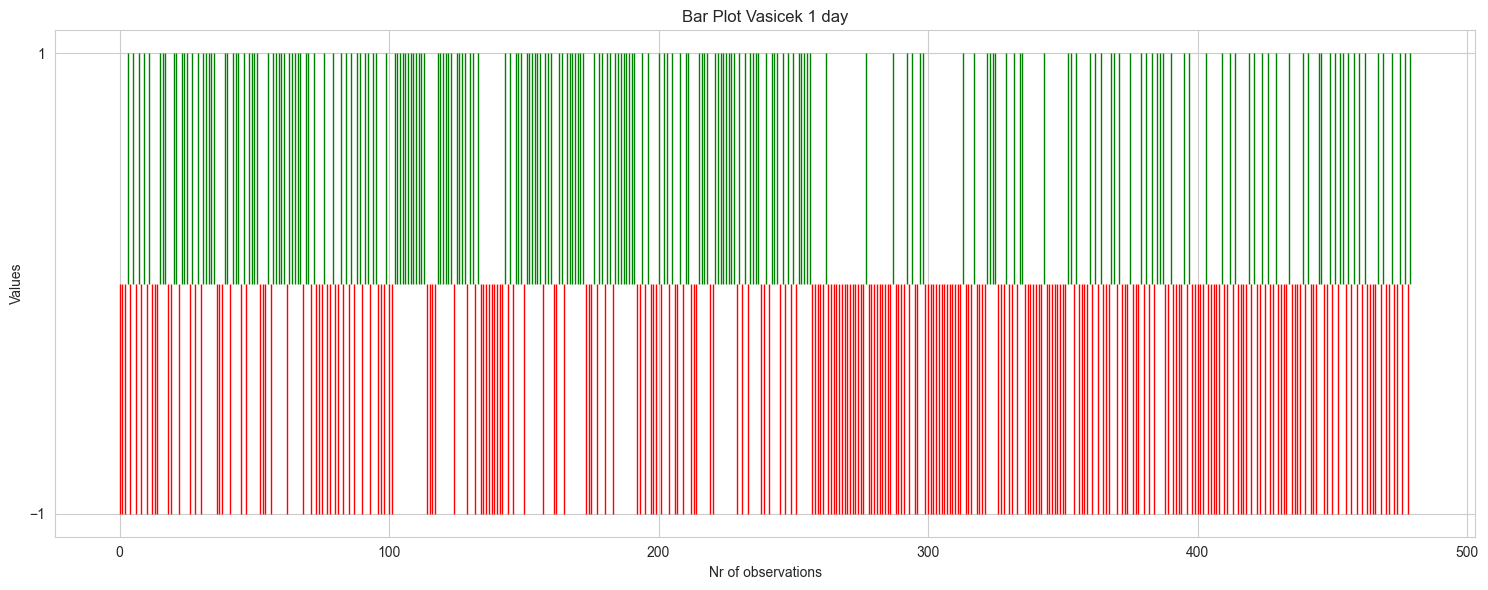

-1    0.539583
 1    0.460417
Name: 1 step ahead, dtype: float64

In [36]:
# 1 day
pos_neg_plot(F_score_VSK_2.iloc[:, 0], 'Bar Plot Vasicek 1 day')

F_score_VSK_2.iloc[:, 0].value_counts(1)

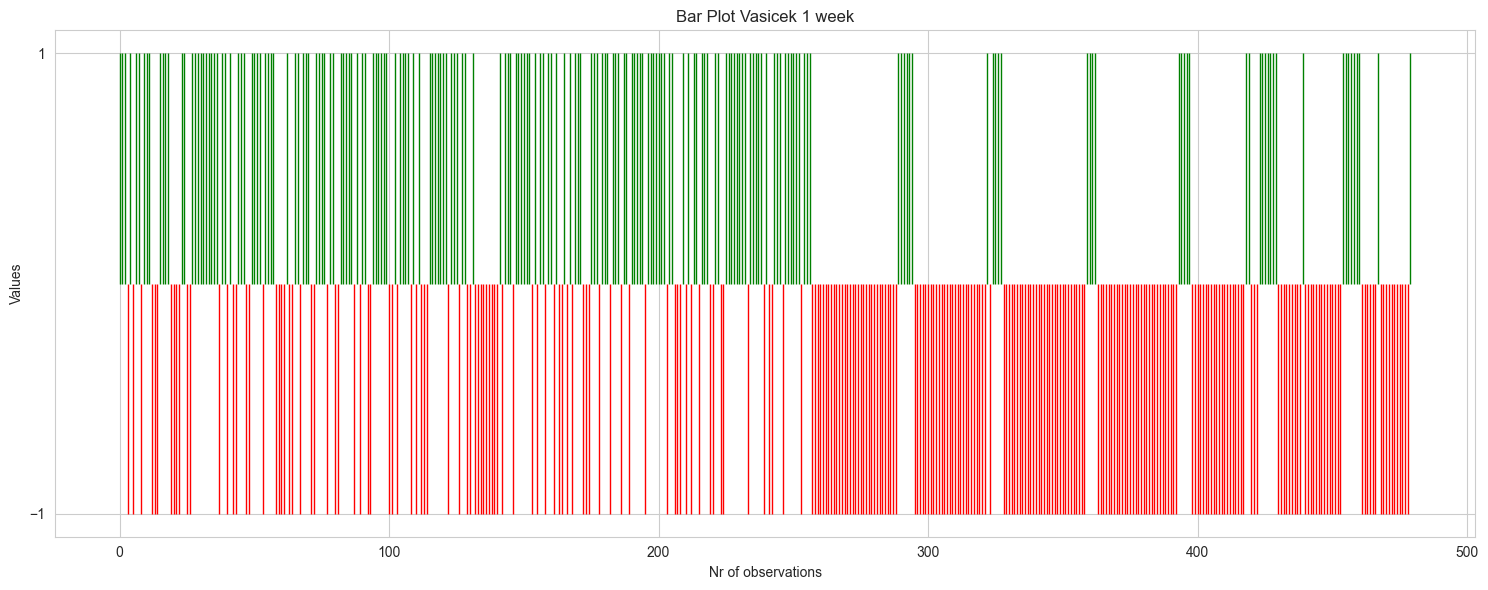

-1    0.572917
 1    0.427083
Name: 7 steps ahead, dtype: float64

In [37]:
# 1 week
pos_neg_plot(F_score_VSK_2.iloc[:, 1], 'Bar Plot Vasicek 1 week')

F_score_VSK_2.iloc[:, 1].value_counts(1)

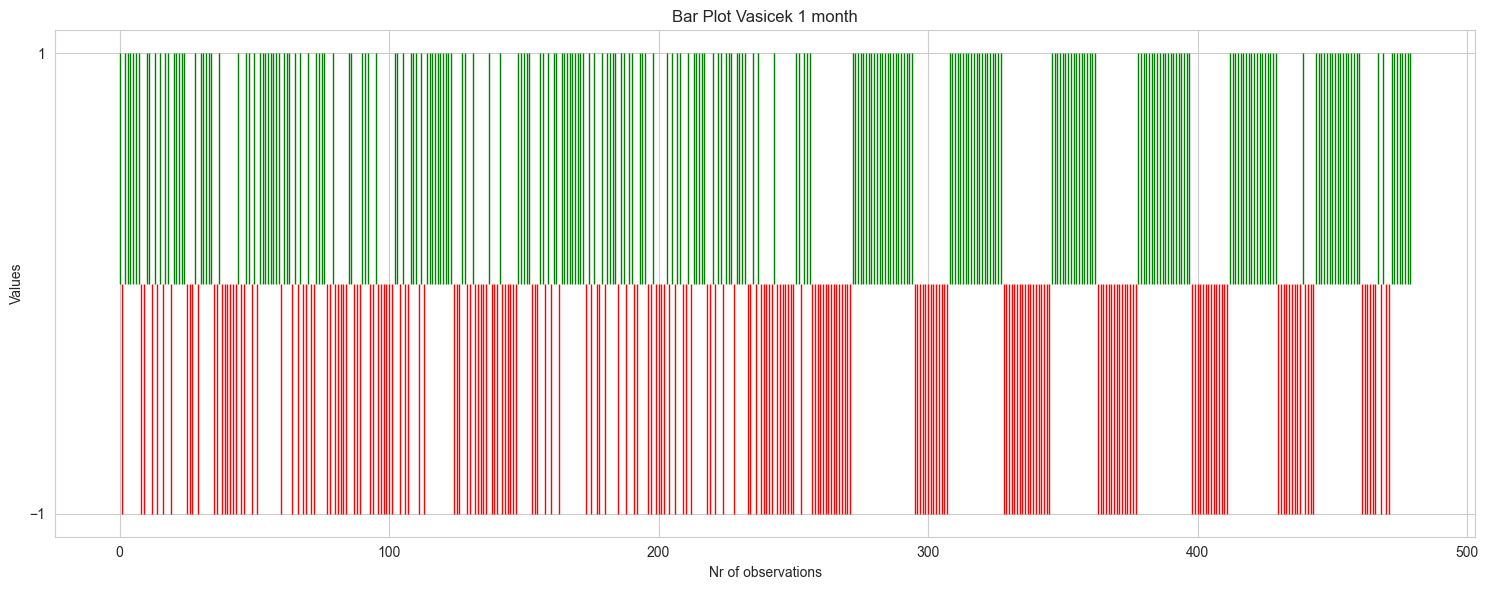

 1    0.55
-1    0.45
Name: 30 steps ahead, dtype: float64

In [38]:
# 1 month
pos_neg_plot(F_score_VSK_2.iloc[:, 2], 'Bar Plot Vasicek 1 month')

F_score_VSK_2.iloc[:, 2].value_counts(1)

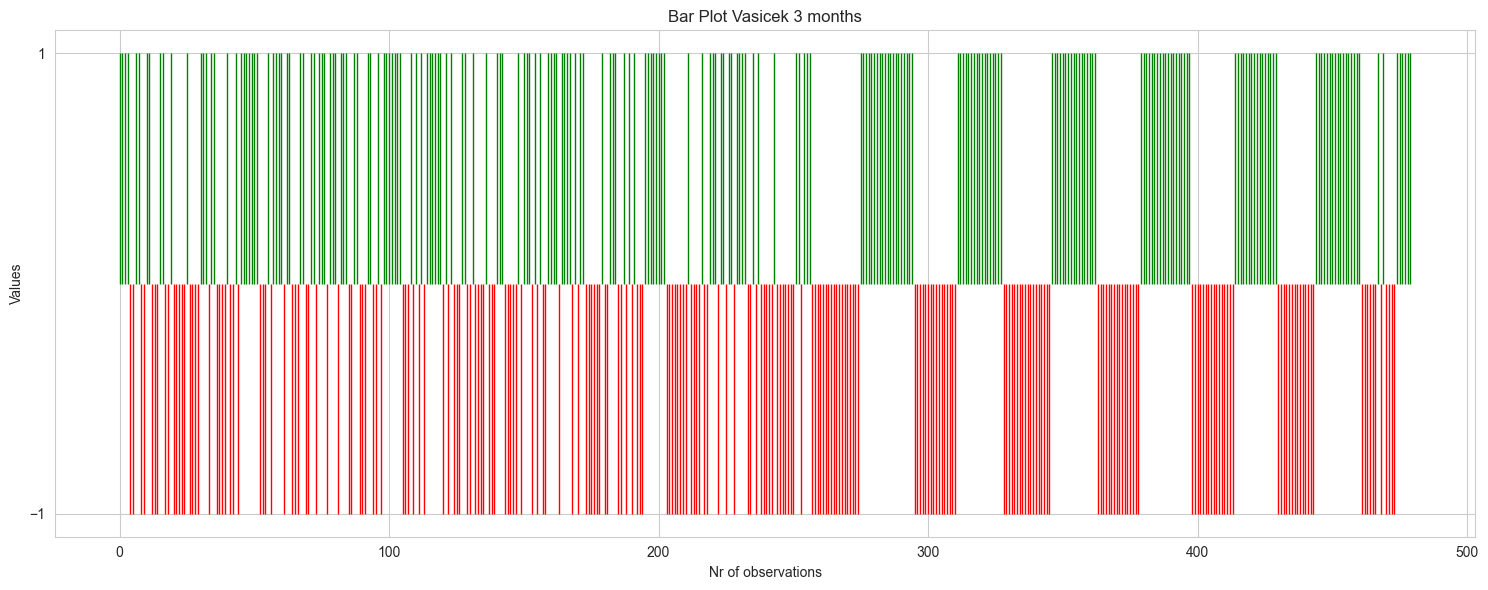

 1    0.50625
-1    0.49375
Name: 90 steps ahead, dtype: float64

In [39]:
# 3 months
pos_neg_plot(F_score_VSK_2.iloc[:, 3], 'Bar Plot Vasicek 3 months')

F_score_VSK_2.iloc[:, 3].value_counts(1)

### CIR

In [40]:
F_score_CIR_2 = F_score_CIR.applymap(change_values)

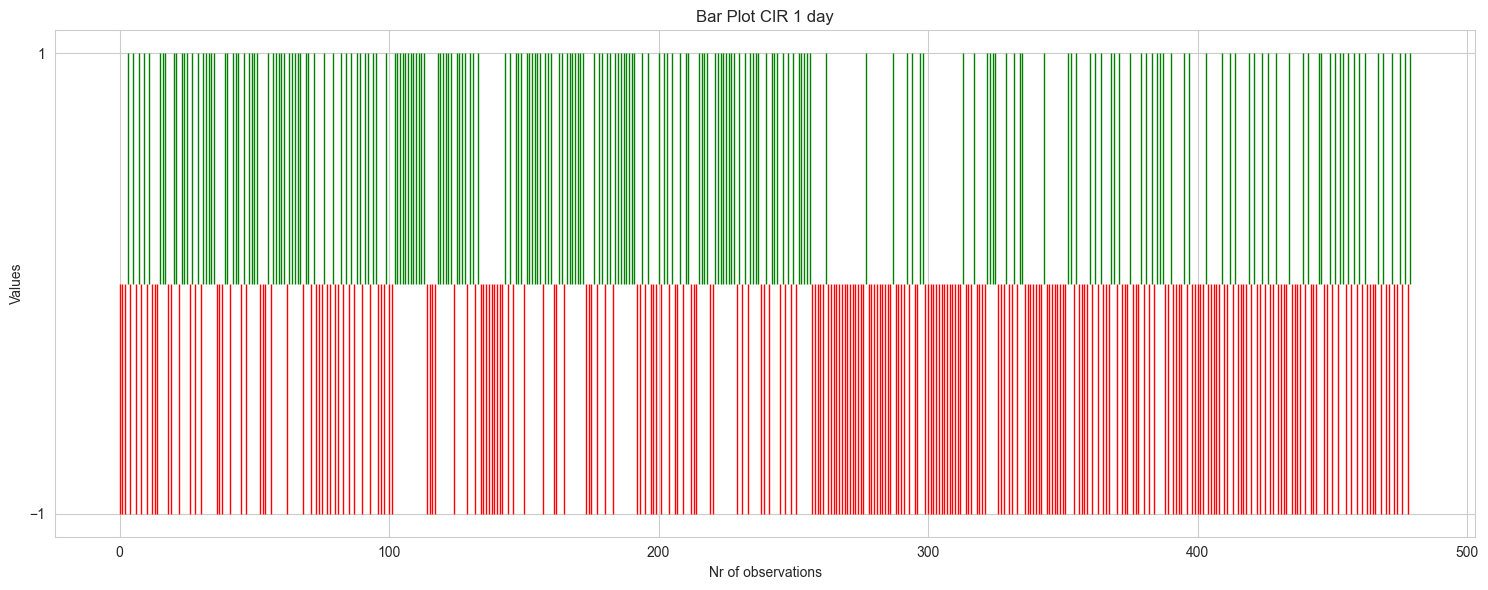

-1    0.539583
 1    0.460417
Name: 1 step ahead, dtype: float64

In [41]:
# 1 day
pos_neg_plot(F_score_CIR_2.iloc[:, 0], 'Bar Plot CIR 1 day')

F_score_CIR_2.iloc[:, 0].value_counts(1)

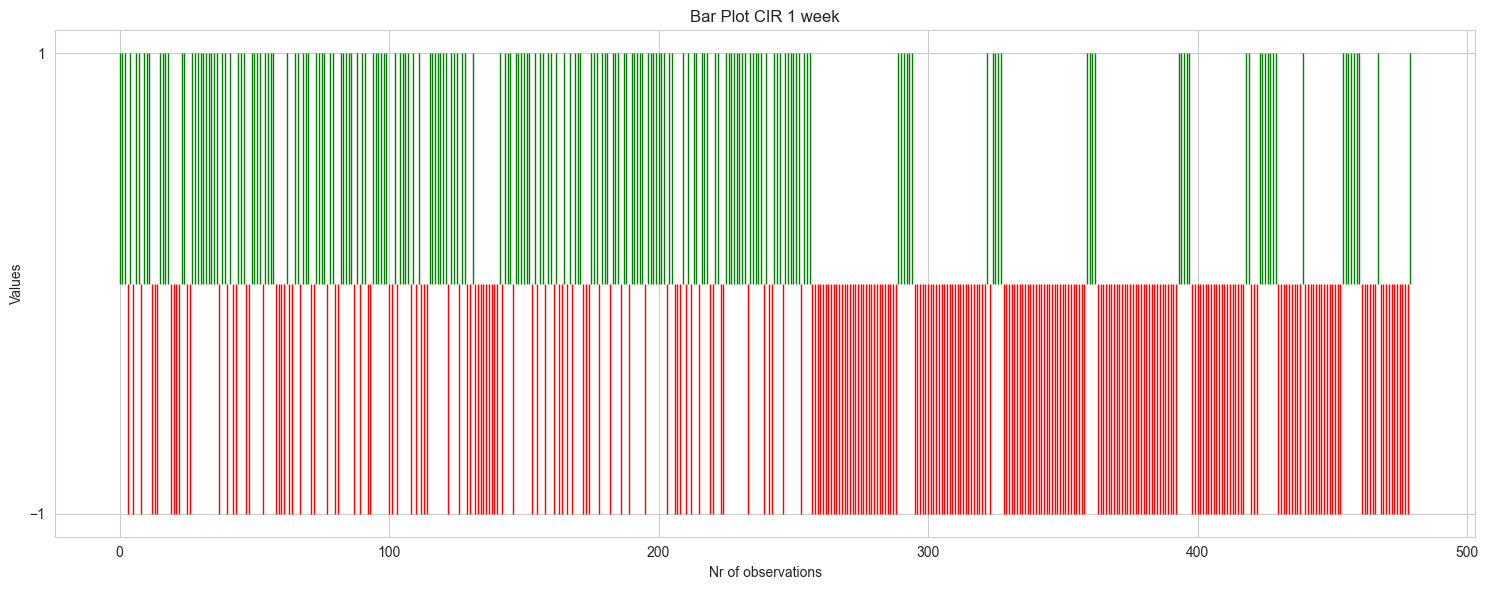

-1    0.572917
 1    0.427083
Name: 7 steps ahead, dtype: float64

In [42]:
# 1 week
pos_neg_plot(F_score_CIR_2.iloc[:, 1], 'Bar Plot CIR 1 week')

F_score_CIR_2.iloc[:, 1].value_counts(1)

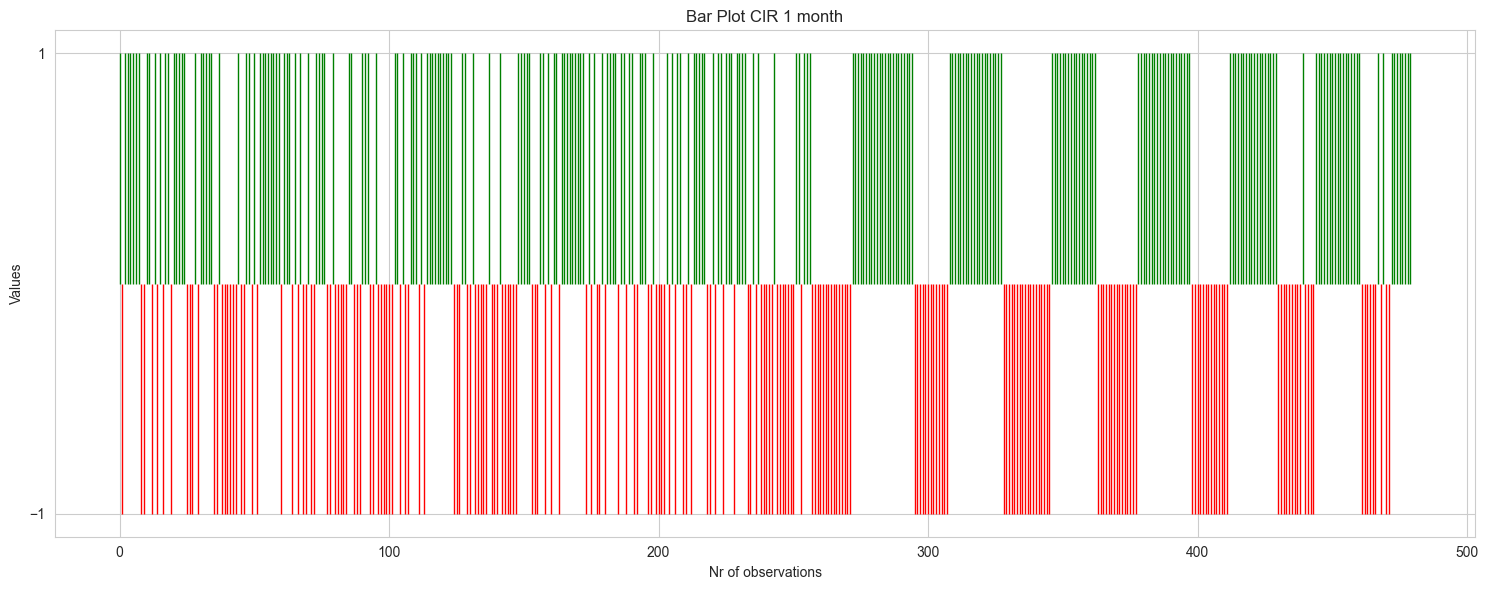

 1    0.55
-1    0.45
Name: 30 steps ahead, dtype: float64

In [43]:
# 1 month
pos_neg_plot(F_score_CIR_2.iloc[:, 2], 'Bar Plot CIR 1 month')

F_score_CIR_2.iloc[:, 2].value_counts(1)

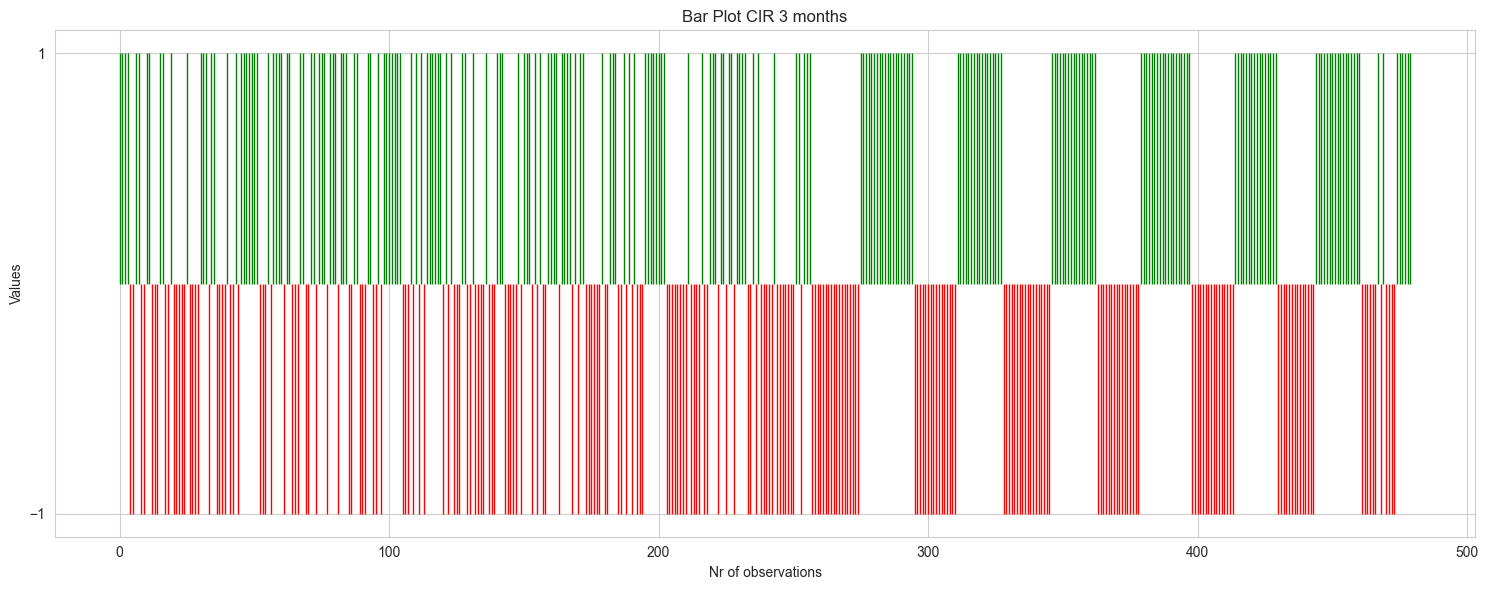

 1    0.50625
-1    0.49375
Name: 90 steps ahead, dtype: float64

In [44]:
# 3 months
pos_neg_plot(F_score_CIR_2.iloc[:, 3], 'Bar Plot CIR 3 months')

F_score_CIR_2.iloc[:, 3].value_counts(1)

### Random Forest

In [45]:
F_score_rf_2 = F_score_rf.applymap(change_values)

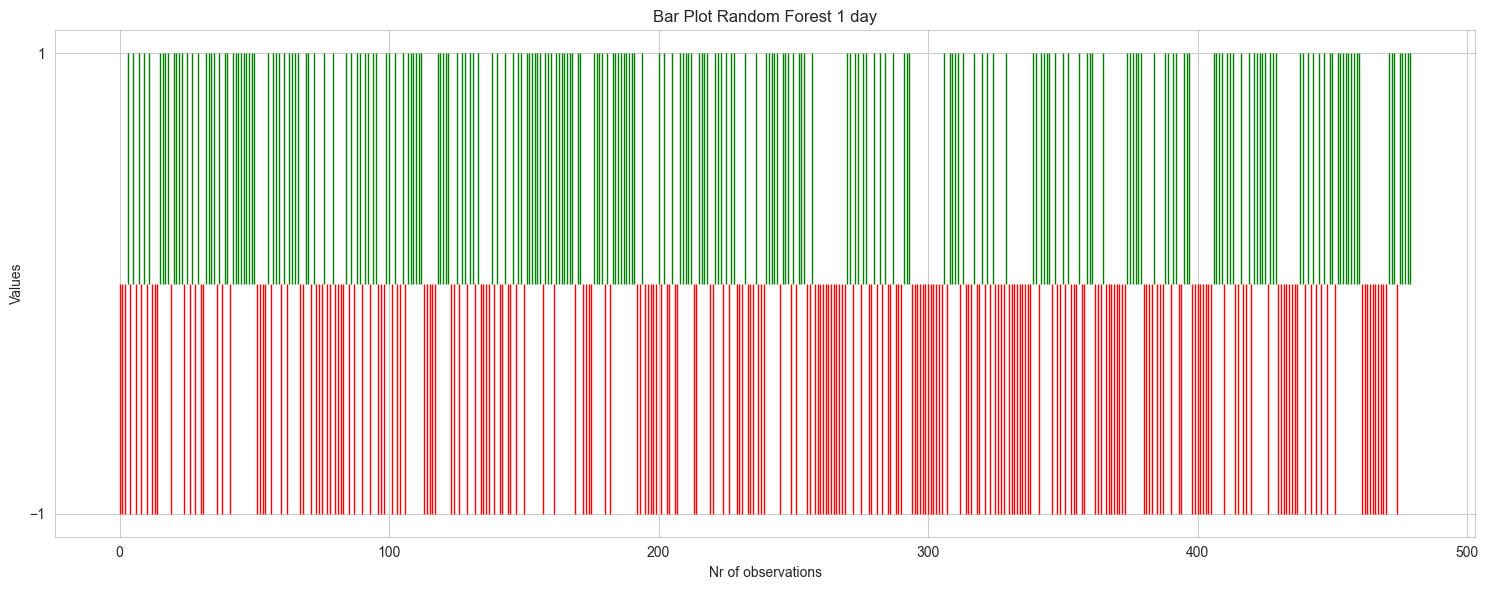

 1    0.502083
-1    0.497917
Name: 1 step ahead, dtype: float64

In [46]:
# 1 day
pos_neg_plot(F_score_rf_2.iloc[:, 0], 'Bar Plot Random Forest 1 day')

F_score_rf_2.iloc[:, 0].value_counts(1)

### LSTM

In [47]:
F_score_LSTM_2 = F_score_LSTM.applymap(change_values)

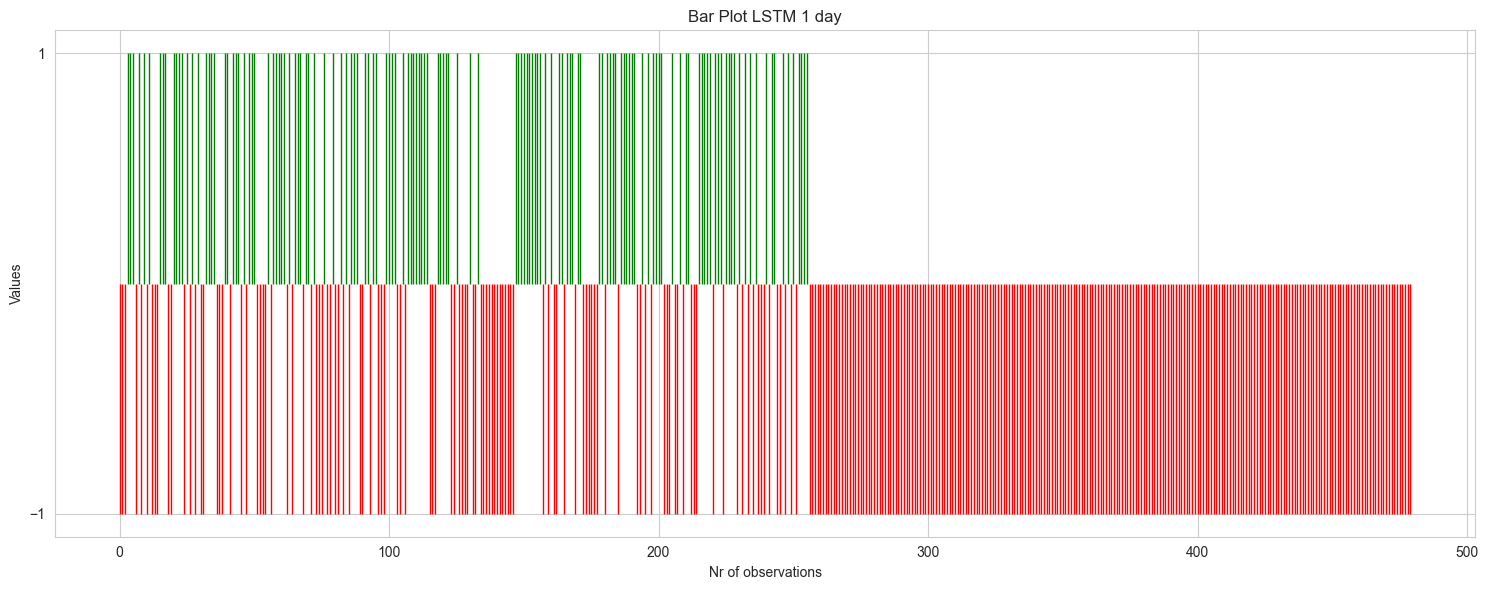

-1    0.70625
 1    0.29375
Name: 1 step ahead, dtype: float64

In [48]:
# 1 day
pos_neg_plot(F_score_LSTM_2.iloc[:, 0], 'Bar Plot LSTM 1 day')

F_score_LSTM_2.iloc[:, 0].value_counts(1)